<font color='blue'>  **3a _______________________ Convection of a Scalar  _______________** </font> <br>
<font color='red'> **____  Whithout implementation  ___** </font> 

In [1]:
from Grid import Grid  ; from ScalarCoeffs import ScalarCoeffs ; from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc ; 
from Models import DiffusionModel, SurfaceConvectionModel   ; from LinearSolver import solve ; from FirstOrderTransientModel import FirstOrderTransientModel 
%matplotlib inline
import matplotlib.pyplot as plt ; import numpy as np  ; from numpy.linalg import norm

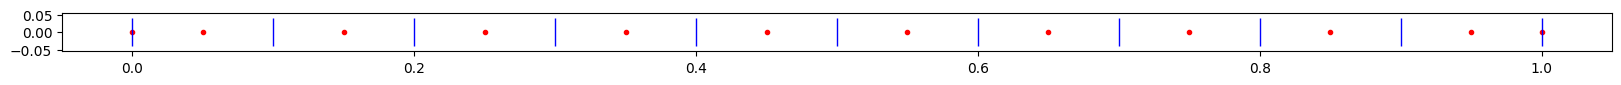

In [2]:
nTime = 10 ; dt = 1 ; time = 0  ; maxIter = 10 ; converged = 1e-6         ; rho = 1000 ; cp = 1000 ; k = 100     ; ho = 25 ; To = 200      # Thermophysical properties | Convection PAR
fig, ax = plt.subplots(figsize=(20, 0.5))                                 ; lx=1.0 ;ly=0.1 ;lz=0.1 ;ncv=10 ; grid = Grid(lx, ly, lz, ncv)                    # centroid | faces
ax.plot  (grid.xP, np.zeros_like(grid.xP), 'o',markersize=3,color='red')  ; ax.plot  (grid.xf, np.zeros_like(grid.xf), '|', markersize=20,color='b')      ; plt.show()

In [3]:
T0 = 300   ; T = T0*np.ones(grid.ncv+2)   ; T_solns = [np.copy(T)]     ; print('T',len(T),T)     ;maxIter = 100  ;coeffs = ScalarCoeffs(grid.ncv) ;converged = 1e-4
#______________init__(self,phi ,grid ,value ,loc) _________________________________________________________________________________________________________________
west_bc = DirichletBc(     T   ,grid ,400   ,BoundaryLocation.WEST)    ;west_bc.apply()         
east_bc = NeumannBc  (T, grid, 0, BoundaryLocation.EAST)               ;east_bc.apply()  

Told = np.copy(T)       ; transient         = FirstOrderTransientModel (grid, T, Told, rho, cp, dt)          # Transient
k=100                   ; diffusion         = DiffusionModel           (grid ,T   ,k    ,west_bc ,east_bc)                            
ho = 25 ; To = 200      ; surfaceConvection = SurfaceConvectionModel   (grid ,T ,ho ,To)

T 12 [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]


In [4]:
%%capture
for tStep in range(nTime):  
    time += dt      ; print("Timestep = {}; Time = {}".format(tStep, time))     ; Told[:] = T[:]

    for i in range(maxIter):
        coeffs.zero()             ;coeffs = diffusion.add(coeffs)  ;coeffs = surfaceConvection.add(coeffs)  ;maxResid = norm(coeffs.rP, np.inf) ;avgResid = np.mean(np.absolute(coeffs.rP))  
        print("Iteration = {}                                                                               ;Max. Resid. = {}                   ;Avg. Resid. = {}".format(i, maxResid, avgResid))
        if maxResid < converged:   break
        dT = solve(coeffs)        ;T[1:-1] += dT                   ;west_bc.apply();east_bc.apply();T_solns.append(np.copy(T))

In [5]:
%%capture
for tStep in range(nTime):  
    time += dt      ; print("Timestep = {}; Time = {}".format(tStep, time))     ; Told[:] = T[:]

    for i in range(maxIter):
        coeffs.zero()             ;coeffs = diffusion.add(coeffs)  ;coeffs = surfaceConvection.add(coeffs)                                       ;coeffs = transient.add(coeffs)
        n='n'                                                                                               ;maxResid = norm(coeffs.rP, np.inf)  ;avgResid = np.mean(np.absolute(coeffs.rP))  
        print("Iteration = {}                                                                               ;Max. Resid. = {}                    ;Avg. Resid. = {}".format(i, maxResid, avgResid))
        if maxResid < converged:   break
        dT = solve(coeffs)        ;T[1:-1] += dT                   ;west_bc.apply();east_bc.apply()     #;T_solns.append(np.copy(T))

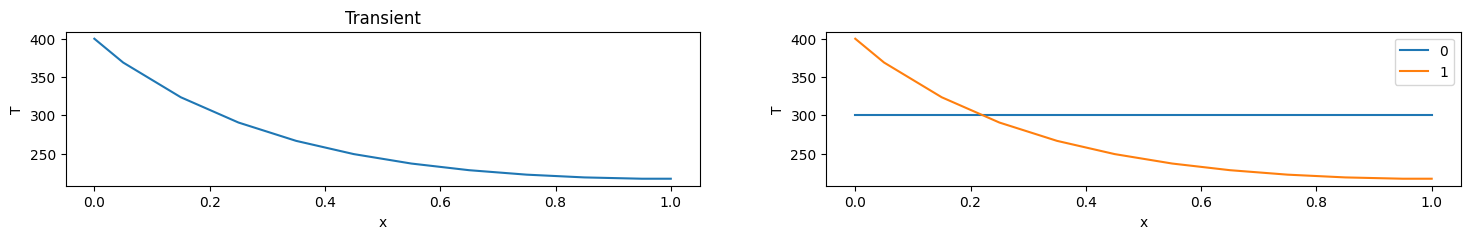

In [6]:
fig = plt.figure(figsize=(18, 2))                                               
ax = fig.add_subplot(121)      ;plt.plot(grid.xP, T) ; plt.xlabel("x") ; plt.ylabel("T")  ; plt.title("Transient")
ax = fig.add_subplot(122)  
for T in T_solns:               plt.plot(grid.xP, T, label=str(i));     i += 1
plt.xlabel("x");plt.ylabel("T");plt.legend();plt.show()